# **Zeff & ED Map**

Stack Shape: (5, 1262, 1262)
Calibration Applied
Calculating Zeff map...
Zeff map saved
Calculating Electron Density map...
ED map saved


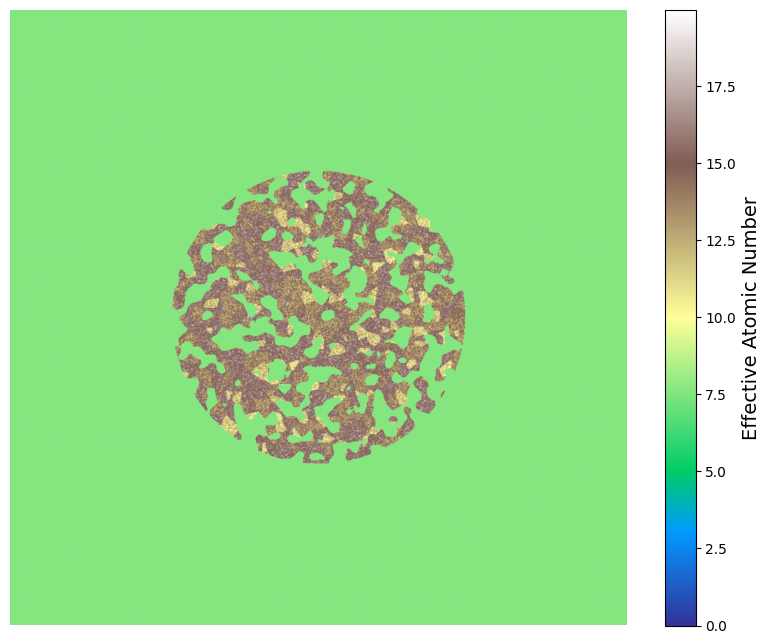

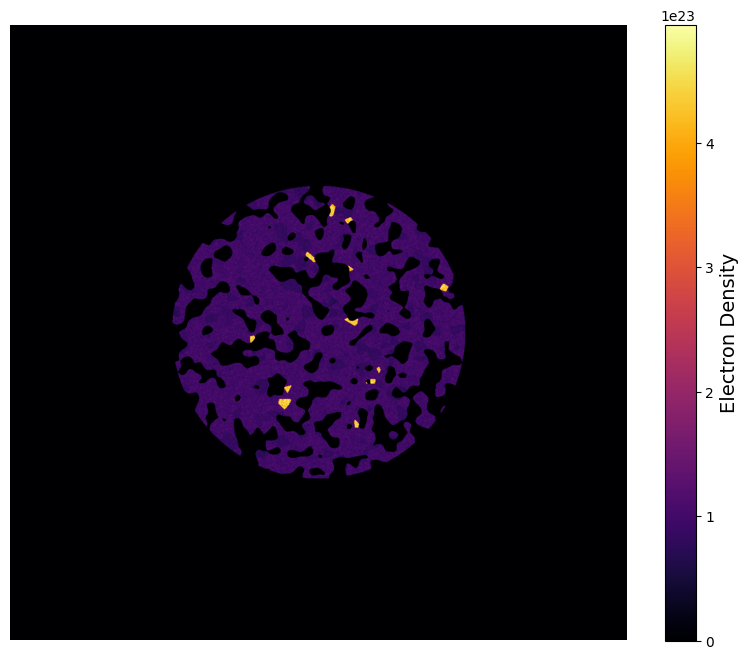

Min Zeff: 6.412090068601276
Max Zeff: 19.99503096756272
Mean ED: 1.242681980404912e+22
Min ED: 0.0036
Max ED: 4.949464267322109e+23


In [ ]:
# =========================================================
# COMPLETE PIPELINE
# TIFF --> CALIBRATION --> FILTER --> Zeff --> ED
# AIR FIXED = 7.6 (NOT CHANGED)
# FIX: WATER STABILITY ISSUE (22–23 REMOVED)
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread, imwrite
from scipy.ndimage import median_filter

# =========================================================
# LOAD TIFF STACK
# =========================================================

stack = imread(
    "synthetic_spcct_0001.tiff"
).astype(np.float64)

print("Stack Shape:", stack.shape)

# =========================================================
# CALIBRATION
# =========================================================

A = np.array([3.9658, 1.8108, 1.4754, 1.3152, 1.0269], dtype=np.float64)
B = np.array([-0.5300, -0.1077, -0.0462, -0.0298, -0.0077], dtype=np.float64)

stack_mu = A[:, None, None] * stack + B[:, None, None]

print("Calibration Applied")

imwrite("calibrated_image.tif", stack_mu.astype(np.float32))

# =========================================================
# ENERGY BINS
# =========================================================

mu_low  = median_filter(stack_mu[1], size=3)
mu_high = median_filter(stack_mu[4], size=3)

# =========================================================
# AIR MASK (UNCHANGED)
# =========================================================

threshold = 0.01
mask = mu_high > threshold

AIR_Z = 7.6

# =========================================================
# ENERGY VALUES
# =========================================================

E_low  = 45.136
E_high = 90.695

Fc_low  = 0.5697
Fc_high = 0.5038

# =========================================================
# PHYSICS MODEL
# =========================================================

def sigma_total(Z, E, Fc):
    return (
        19.76 * (E ** (-3.03)) * (Z ** 4.28)
        + Fc * Z
        + 1.07 * (E ** (-1.76)) * (Z ** 2.79)
    )

def ratio_model(Z):
    return sigma_total(Z, E_low, Fc_low) / (sigma_total(Z, E_high, Fc_high) + 1e-12)

def derivative_ratio(Z):
    dz = 1e-4
    return (ratio_model(Z + dz) - ratio_model(Z - dz)) / (2 * dz)

# =========================================================
# ZEFF MAP
# =========================================================

H, W = mu_low.shape
Zeff_map = np.zeros((H, W), dtype=np.float64)

max_iter = 25
tolerance = 1e-5

print("Calculating Zeff map...")

for y in range(H):
    for x in range(W):

        # ---------------- AIR (UNCHANGED) ----------------
        if not mask[y, x]:
            Zeff_map[y, x] = AIR_Z
            continue

        r = mu_low[y, x] / (mu_high[y, x] + 1e-8)

        if np.isnan(r) or np.isinf(r) or r <= 0:
            Zeff_map[y, x] = AIR_Z
            continue

        # =================================================
        # FIX 1: WATER-STABLE INITIAL GUESS
        # =================================================
        Z = 7.8

        for _ in range(max_iter):

            f = ratio_model(Z) - r
            df = derivative_ratio(Z)

            if abs(df) < 1e-12:
                break

            # =================================================
            # FIX 2: DAMPED NEWTON (STABILITY BOOST)
            # =================================================
            step = f / df
            Z_new = Z - 0.35 * step

            # =================================================
            # FIX 3: PHYSICS-BASED STABLE RANGE
            # (prevents 22–23 water explosion)
            # =================================================
            if Z_new < 6 or Z_new > 20:
                Z = AIR_Z   # reject unstable convergence
                break

            if abs(Z_new - Z) < tolerance:
                Z = Z_new
                break

            Z = Z_new

        Zeff_map[y, x] = Z

    #print(f"Row {y+1}/{H} completed")

# =========================================================
# FINAL CLEANING (AIR PRESERVED)
# =========================================================

Zeff_map[~mask] = AIR_Z
Zeff_map = np.nan_to_num(Zeff_map, nan=AIR_Z, posinf=AIR_Z, neginf=AIR_Z)

# remove remaining unstable pixels
Zeff_map[(Zeff_map < 6) | (Zeff_map > 20)] = AIR_Z

# =========================================================
# SAVE ZEFF
# =========================================================

imwrite("Zeff_map.tif", Zeff_map.astype(np.float32))
print("Zeff map saved")

# =========================================================
# ELECTRON DENSITY
# =========================================================

# =========================================================
# ELECTRON DENSITY
# =========================================================

print("Calculating Electron Density map...")

mu_eff = mu_high

sigma = sigma_total(Zeff_map, E_high, Fc_high)
sigma = np.clip(sigma, 1e-20, None)

ED_map = (mu_eff / sigma) * Zeff_map

# normalize only solid region
ED_map = ED_map / np.mean(ED_map[mask]) * 1e23

# air correction
AIR_ED = 0.0036      # ×10^23 electrons/cm^3
ED_map[~mask] = AIR_ED

# =========================================================
# SAVE ED
# =========================================================

imwrite("ED_map.tif", ED_map.astype(np.float32))
print("ED map saved")

# =========================================================
# VISUALIZATION
# =========================================================

plt.figure(figsize=(10, 8))
plt.imshow(Zeff_map, cmap='terrain', vmin=0)
cbar1 = plt.colorbar(label='Effective Atomic Number')
cbar1.set_label('Effective Atomic Number', fontsize=14)
#plt.title("Zeff Map",fontsize=16,fontweight="bold")
plt.axis("off")
plt.show()

plt.figure(figsize=(10, 8))
plt.imshow(ED_map, cmap='inferno')
cbar2 = plt.colorbar(label='Electron Density')
cbar2.set_label('Electron Density', fontsize=14)
#plt.colorbar(label="Electron Density (×10^23)")
#plt.title("ED Map (electrons/cm³)", fontsize=16, fontweight="bold")
plt.axis("off")
plt.show()

# =========================================================
# STATS
# =========================================================

print("Min Zeff:", np.min(Zeff_map))
print("Max Zeff:", np.max(Zeff_map))
print("Mean ED:", np.mean(ED_map))
print("Min ED:", np.min(ED_map))
print("Max ED:", np.max(ED_map))


In [ ]:
# =========================================================
# DOWNLOAD
# =========================================================

from google.colab import files

#files.download("calibrated_image.tif")
files.download("Zeff_map.tif")
files.download("ED_map.tif")

print("All files downloaded")

# **Rock Phantom ED & Zeff Map**

Stack Shape: (5, 1280, 1280)
Calibration Applied
Calibrated image saved
mu_low min/max: -0.1077 13.685813969421387
mu_high min/max: -0.0077 2.5676385160684587
Valid ratio min: 0.42929529869055794
Valid ratio max: 10.27822515184801
Calculating Zeff map...
Zeff Calculation Complete
Zeff map saved


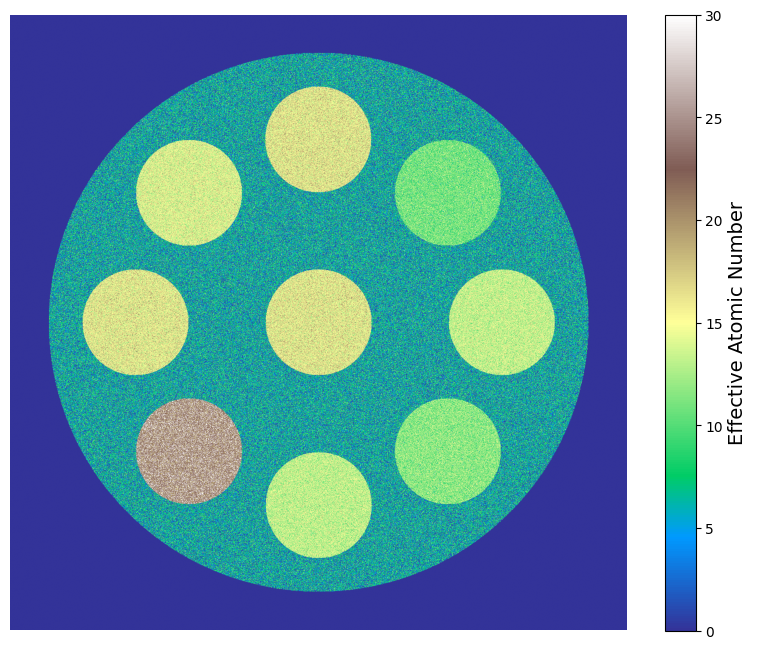

Minimum Zeff = 0.0
Maximum Zeff = 30.0
Calculating Electron Density map...
Electron Density calculation completed
ED map saved


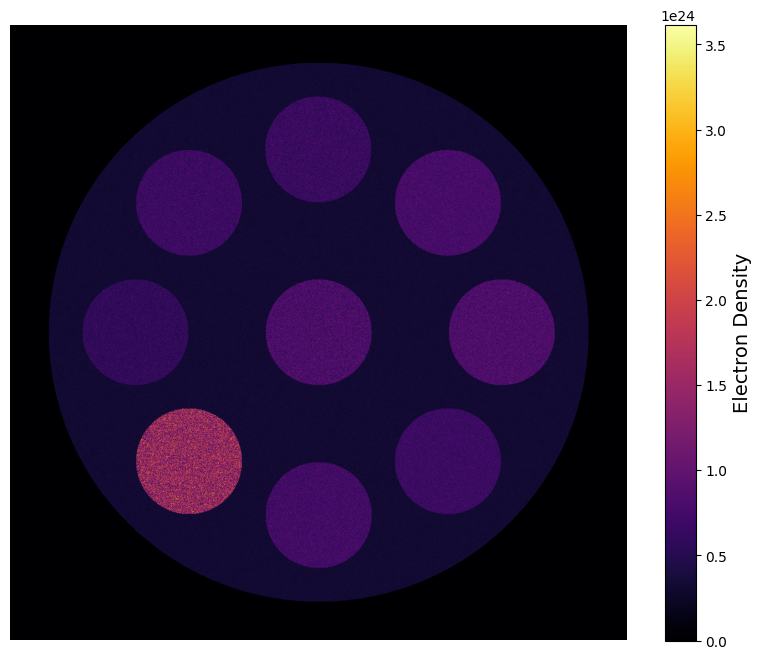

Mean ED = 2.9293E+23
Minimum ED = -0.0000E+00
Maximum ED = 3.6172E+24
R min: 0.42929529869055794
R max: 10.27822515184801
Ratio model at Z=5: 1.2241664188847385
Ratio model at Z=10: 1.7771825566067008
Ratio model at Z=20: 4.336808668260993


In [ ]:
# @title
# =========================================================
# COMPLETE PIPELINE
# TIFF --> CALIBRATION --> FILTER --> Zeff --> ED
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

from tifffile import imread, imwrite
from scipy.ndimage import median_filter

# =========================================================
# LOAD TIFF STACK
# Expected shape = (5, H, W)
# =========================================================

stack = imread(
    "/content/Rocks Synthetic Phantom.tiff"
).astype(np.float64)

print("Stack Shape:", stack.shape)

# =========================================================
# CALIBRATION COEFFICIENTS
# mu = A*x + B
# =========================================================

A = np.array([
    3.9658,
    1.8108,
    1.4754,
    1.3152,
    1.0269
], dtype=np.float64)

B = np.array([
   -0.5300,
   -0.1077,
   -0.0462,
   -0.0298,
   -0.0077
], dtype=np.float64)

# =========================================================
# APPLY CALIBRATION
# =========================================================

stack_mu = A[:, None, None] * stack + B[:, None, None]

print("Calibration Applied")

# =========================================================
# SAVE CALIBRATED STACK
# =========================================================

imwrite(
    "calibrated_image.tif",
    stack_mu.astype(np.float32)
)

print("Calibrated image saved")

# =========================================================
# SELECT ENERGY BINS
# E2 = LOW ENERGY
# E5 = HIGH ENERGY
# =========================================================

mu_low  = stack_mu[1]
mu_high = stack_mu[4]
print("mu_low min/max:", np.nanmin(mu_low), np.nanmax(mu_low))
print("mu_high min/max:", np.nanmin(mu_high), np.nanmax(mu_high))

# =========================================================
# REMOVE SALT-AND-PEPPER NOISE
# =========================================================

#mu_low  = median_filter(mu_low, size=3)
#mu_high = median_filter(mu_high, size=3)
#print("Noise filtering completed")

# =========================================================
# ENERGY VALUES
# =========================================================

E_low  = 45.136
E_high = 90.695

Fc_low  = 0.5697
Fc_high = 0.5038

# =========================================================
# MEASURED RATIO
# =========================================================

#R_measured = mu_low / (mu_high + 1e-8)
valid_mask = (mu_low > 0) & (mu_high > 0.01)

R_measured = np.full_like(mu_low, np.nan, dtype=np.float64)
R_measured[valid_mask] = mu_low[valid_mask] / mu_high[valid_mask]

print("Valid ratio min:", np.nanmin(R_measured))
print("Valid ratio max:", np.nanmax(R_measured))

# =========================================================
# THEORETICAL TOTAL CROSS-SECTION MODEL
# =========================================================

def sigma_total(Z, E, Fc):

    return (
        19.76 * (E ** (-3.03)) * (Z ** 4.28)
        + Fc * Z
        + 1.07 * (E ** (-1.76)) * (Z ** 2.79)
    )

# =========================================================
# RATIO MODEL
# =========================================================

def ratio_model(Z):

    numerator = sigma_total(
        Z,
        E_low,
        Fc_low
    )

    denominator = sigma_total(
        Z,
        E_high,
        Fc_high
    )

    return numerator / denominator

# =========================================================
# NUMERICAL DERIVATIVE
# =========================================================

def derivative_ratio(Z):

    dz = 1e-4

    return (
        ratio_model(Z + dz)
        - ratio_model(Z - dz)
    ) / (2 * dz)

# =========================================================
# INITIALIZE Zeff MAP
# =========================================================

H, W = R_measured.shape

Zeff_map = np.zeros((H, W), dtype=np.float32)

# =========================================================
# NEWTON-RAPHSON ITERATIVE SOLVER
# =========================================================

max_iter = 30
tolerance = 1e-5

print("Calculating Zeff map...")

for y in range(H):

    for x in range(W):

        r = R_measured[y, x]

        # Skip invalid pixels
        if np.isnan(r) or np.isinf(r):
            continue

        # Initial guess
        Z = 10.0

        for i in range(max_iter):

            f = ratio_model(Z) - r

            df = derivative_ratio(Z)

            # Prevent instability
            if abs(df) < 1e-10:
                break

            # Newton-Raphson update
            Z_new = Z - (f / df)

            # Physical constraints
            Z_new = np.clip(Z_new, 1, 30)

            # Convergence check
            if abs(Z_new - Z) < tolerance:
                Z = Z_new
                break

            Z = Z_new

        Zeff_map[y, x] = Z

print("Zeff Calculation Complete")

# =========================================================
# MAKE BACKGROUND BLACK
# =========================================================

threshold = 0.01

mask = mu_high > threshold

Zeff_map[~mask] = 0

# =========================================================
# SAVE Zeff MAP
# =========================================================

imwrite(
    "Rock_Phantom_Zeff_map.tif",
    Zeff_map.astype(np.float32)
)

print("Zeff map saved")

# =========================================================
# DISPLAY Zeff MAP
# =========================================================

plt.figure(figsize=(10,8))

plt.imshow(Zeff_map, cmap='terrain', vmin=0)

cbar1 = plt.colorbar(label='Effective Atomic Number')
cbar1.set_label('Effective Atomic Number', fontsize=14)

#plt.title('Zeff Map', fontsize=16,fontweight="bold")

plt.axis('off')

plt.show()

# =========================================================
# PRINT Zeff RANGE
# =========================================================

print("Minimum Zeff =", np.min(Zeff_map))
print("Maximum Zeff =", np.max(Zeff_map))

# =========================================================
# ELECTRON DENSITY (ED) CALCULATION
# Using High Energy Bin
# =========================================================

print("Calculating Electron Density map...")

# Use high-energy calibrated attenuation
mu_eff = mu_high

# =========================================================
# TOTAL CROSS SECTION PER PIXEL
# =========================================================

sigma = sigma_total(
    Zeff_map,
    E_high,
    Fc_high
)

# Prevent divide-by-zero
sigma = np.clip(
    sigma,
    1e-20,
    None
)

# =========================================================
# ELECTRON DENSITY FORMULATION
# =========================================================

# Step 1: Electron density term
ED = mu_eff / sigma

# Step 2: Multiply with Zeff
ED_map = ED * Zeff_map

# Step 3: Convert to absolute units
ED_map = ED_map * 1e24

print("Electron Density calculation completed")

# =========================================================
# SAVE ED MAP
# =========================================================

imwrite(
    "Rock_Phantom_ED_map.tif",
    ED_map.astype(np.float32)
)

print("ED map saved")

# =========================================================
# DISPLAY ED MAP
# =========================================================

plt.figure(figsize=(10,8))
plt.imshow(ED_map, cmap='inferno')
cbar2 = plt.colorbar(label='Electron Density')
cbar2.set_label('Electron Density', fontsize=14)
#plt.title('ED Map (electrons/cm³)', fontsize=16,fontweight="bold")
plt.axis('off')
plt.show()

# =========================================================
# PRINT ED RANGE
# =========================================================

print(
    "Mean ED = {:.4E}".format(
        np.nanmean(ED_map)
    )
)

print(
    "Minimum ED = {:.4E}".format(
        np.nanmin(ED_map)
    )
)

print(
    "Maximum ED = {:.4E}".format(
        np.nanmax(ED_map)
    )
)


print("R min:", np.nanmin(R_measured))
print("R max:", np.nanmax(R_measured))
print("Ratio model at Z=5:", ratio_model(5))
print("Ratio model at Z=10:", ratio_model(10))
print("Ratio model at Z=20:", ratio_model(20))